In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
CA1_path <-paste0(indir,"/03_H3K4me1_Allsubclass/CA1/")
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_CT.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L4_Rorb.mm10.tmp"
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L5.mm10.tmp"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_L6.mm10.tmp"     
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_FC_NP.mm10.tmp"     
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_CA1.mm10.tmp"    
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_CA23.mm10.tmp"   
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_HC_DG.mm10.tmp"     
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_CGE.mm10.tmp"    
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_Pvalb.mm10.tmp"  
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass/CA1//Paired-Tag_H3K4me1_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me1_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me1_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me1_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me1_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,CT_signal_sum,CT_signal_sum_log10,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,⋯,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,CGE_signal_sum,CGE_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,144.491040,2.1628362,0.000000,0.0000000,0.000000,0.0000000,0.00000,0.000000,0.000000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:3868330-3869330,69.355680,1.8472992,0.000000,0.0000000,0.000000,0.0000000,0.00000,0.000000,124.287980,⋯,33.05182,1.532140,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4000851-4001851,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.00000,0.000000,0.000000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4017553-4018553,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.00000,0.000000,0.000000,⋯,0.00000,0.000000,81.27014,1.915242,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4168027-4169027,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.00000,0.000000,0.000000,⋯,0.00000,0.000000,30.29283,1.495445,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:4249638-4250638,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.00000,0.000000,0.000000,⋯,0.00000,0.000000,0.00000,0.000000,28.26791,1.466392,0.0000,0.000000,0.00000,0.000000
chr1:4454449-4455449,115.881802,2.0677469,19.028946,1.3016581,0.000000,0.0000000,0.00000,0.000000,0.000000,⋯,82.35415,1.920927,0.00000,0.000000,457.26536,2.661117,1373.9435,3.138285,447.89114,2.652141
chr1:4794017-4795017,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.00000,0.000000,0.000000,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000
chr1:5336791-5337791,17.049958,1.2564762,118.426186,2.0770996,282.928378,2.4532088,282.99586,2.453312,887.770400,⋯,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.0000,0.000000,0.00000,0.000000


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,2.1628362,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.641426,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,1.8472992,0.0000000,0.0000000,0.000000,2.0979094,0.000000,0.000000,1.532140,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,1.915242,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,1.495445,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.138681,0.000000,0.000000,1.466392,0.000000,0.000000
chr1:4454449-4455449,2.0677469,1.3016581,0.0000000,0.000000,0.0000000,0.000000,0.000000,1.920927,0.000000,2.661117,3.138285,2.652141
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.458409,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,1.2564762,2.0770996,2.4532088,2.453312,2.9487896,0.000000,2.737559,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,2.1628362,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.641426,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,1.8472992,0.0000000,0.0000000,0.000000,2.0979094,0.000000,0.000000,1.532140,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,1.915242,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,1.495445,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.138681,0.000000,0.000000,1.466392,0.000000,0.000000
chr1:4454449-4455449,2.0677469,1.3016581,0.0000000,0.000000,0.0000000,0.000000,0.000000,1.920927,0.000000,2.661117,3.138285,2.652141
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.458409,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,1.2564762,2.0770996,2.4532088,2.453312,2.9487896,0.000000,2.737559,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,CT,L2_3,L4_Rorb,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,2.1628362,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.641426,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,1.8472992,0.0000000,0.0000000,0.000000,2.0979094,0.000000,0.000000,1.532140,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,1.915242,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,1.495445,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.138681,0.000000,0.000000,1.466392,0.000000,0.000000
chr1:4454449-4455449,2.0677469,1.3016581,0.0000000,0.000000,0.0000000,0.000000,0.000000,1.920927,0.000000,2.661117,3.138285,2.652141
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.458409,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,1.2564762,2.0770996,2.4532088,2.453312,2.9487896,0.000000,2.737559,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,CT,L2_3,L4,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,2.1628362,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.641426,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,1.8472992,0.0000000,0.0000000,0.000000,2.0979094,0.000000,0.000000,1.532140,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,1.915242,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,1.495445,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.138681,0.000000,0.000000,1.466392,0.000000,0.000000
chr1:4454449-4455449,2.0677469,1.3016581,0.0000000,0.000000,0.0000000,0.000000,0.000000,1.920927,0.000000,2.661117,3.138285,2.652141
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.000000,2.458409,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,1.2564762,2.0770996,2.4532088,2.453312,2.9487896,0.000000,2.737559,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,CT,L2_3,L4,NP,CA1,CA23,DG,CGE,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,2.1628362,0.0000000,0.0000000,0.000000,2.641426,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:3868330-3869330,1.8472992,0.0000000,0.0000000,0.000000,0.000000,1.532140,0.000000,0.000000,0.000000,0.000000,1.0489547
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:4017553-4018553,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,1.915242,0.000000,0.000000,0.000000,0.0000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,1.495445,0.000000,0.000000,0.000000,0.0000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,0.000000,2.138681,0.000000,0.000000,1.466392,0.000000,0.000000,0.0000000
chr1:4454449-4455449,2.0677469,1.3016581,0.0000000,0.000000,0.000000,1.920927,0.000000,2.661117,3.138285,2.652141,0.0000000
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,0.000000,2.458409,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000
chr1:5336791-5337791,1.2564762,2.0770996,2.4532088,0.000000,2.737559,0.000000,0.000000,0.000000,0.000000,0.000000,2.7010508


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "NP"    "CT"    "DG"    "CGE"  
[10] "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.0000000,2.641426,0.000000,0.000000,2.1628362,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.0000000,1.0489547,0.000000,1.532140,0.000000,1.8472992,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,1.915242,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,1.495445,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,2.138681,0.000000,0.000000,0.0000000,0.000000,1.466392,0.000000,0.000000
chr1:4454449-4455449,1.3016581,0.0000000,0.0000000,0.000000,1.920927,0.000000,2.0677469,0.000000,2.661117,3.138285,2.652141
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,2.458409,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,2.0770996,2.4532088,2.7010508,2.737559,0.000000,0.000000,1.2564762,0.000000,0.000000,0.000000,0.000000


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
.,1.157399,0.756719,0.7746908,1.254716,0.9562553,0.3020947,0.7399862,1.074431,0.6509507,0.5053763,0.5195472


In [19]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


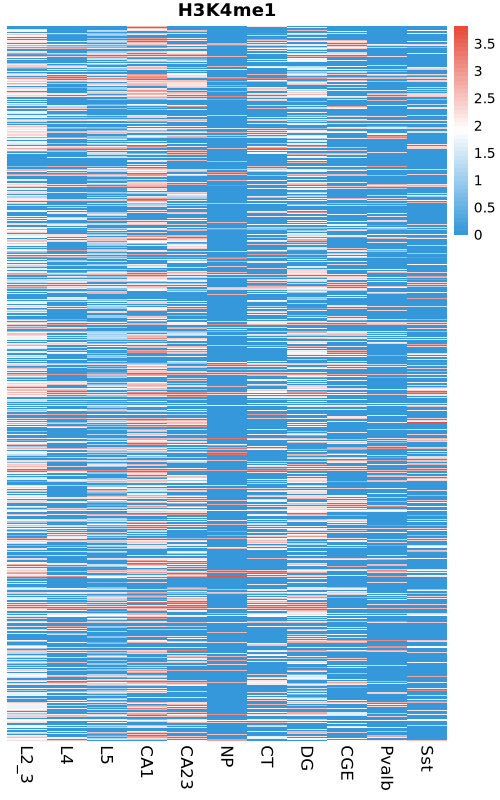

In [20]:
options(repr.plot.width = 5, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  merged_CA1,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  show_rownames = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me1",
  fontsize_row = 12,
  fontsize_col = 12 
)

In [21]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3", "L4", "L5", "CA1", "CA23", "NP", "CT", "DG", "CGE", "Pvalb", "Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K4me1_path <- paste0(indir,"/03_H3K4me1_Allsubclass/")

In [23]:
subdirs <- list.dirs(path = H3K4me1_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//CT"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//DG"   
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//L2_3" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//L4_5" 
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//L5"   
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//Lamp5"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//NP"   
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//Pvalb"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//Sncg" 
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/Histone/Paired-Tag_DMR_20241229/output/03_H3K4me1_Allsubclass//Sst"

In [24]:
basename(subdirs)

[1] "CA1"   "CA23"  "CT"    "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "NP"   
[10] "Pvalb" "Sncg"  "Sst"

In [ ]:
L2_3 <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/L2_3'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:40205252-40206252,1.8251989,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,1.4381123,0.000000,0.000000,0.0000000
chr1:63801436-63802436,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000
chr1:95910578-95911578,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000
chr1:121992418-121993418,2.1920938,0.000000,0.0000000,0.0000000,1.416046,0.000000,0.0000000,1.2970222,0.000000,0.000000,0.0000000
chr1:123860055-123861055,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000
chr1:127035082-127036082,2.6445557,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.0000000,1.7311500,0.000000,1.810921,0.0000000
chr1:165699424-165700424,2.8321883,2.427573,1.8773823,0.0000000,0.000000,0.000000,2.6268456,0.0000000,0.000000,2.967804,0.0000000
chr1:184865166-184866166,2.2442200,2.167786,1.6850591,2.7084785,0.000000,0.000000,2.1488102,2.0493325,2.343206,0.000000,0.9553664
chr2:10595247-10596247,2.0181531,0.000000,0.9925123,2.1455212,0.000000,0.000000,0.0000000,0.8616589,2.282868,0.000000,0.0000000


In [26]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.267074,0.8885921,0.7987047,0.631087,0.6165823,0.214142,0.5971059,0.7749214,0.4688707,0.4216562,0.3426534


In [ ]:
L4_5 <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/L4_5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3989606-3990606,1.962502,0.0000000,1.5028031,0.000000,0.000000,0.000000,2.2109636,1.8307447,1.899707,0.000000,2.323357
chr1:7536517-7537517,0.000000,2.4894711,1.1879151,0.000000,1.575562,0.000000,0.0000000,0.0000000,1.737549,0.000000,0.000000
chr1:9780815-9781815,2.478397,0.5246949,2.7405086,0.000000,2.142126,0.000000,2.3291982,1.8307447,0.000000,0.000000,0.000000
chr1:14839073-14840073,1.036185,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:14914779-14915779,0.000000,2.3677783,1.4989292,0.000000,0.000000,2.731937,0.0000000,2.4279680,2.208476,0.000000,0.000000
chr1:17756423-17757423,2.141651,2.6450948,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,2.897236,0.000000,0.000000
chr1:22023298-22024298,2.001959,0.0000000,0.0000000,0.000000,1.185328,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:23137109-23138109,2.062584,2.7643641,0.0000000,0.000000,0.000000,0.000000,0.0000000,1.8307447,0.000000,2.439512,2.531310
chr1:26269966-26270966,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000


In [28]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L4_5,1.5001,1.386488,1.118767,0.7873805,0.7894163,0.3520447,0.8686346,0.9661003,0.6877859,0.5855268,0.6183664


In [ ]:
L5 <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/L5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4185672-4186672,0.0000000,2.186762,2.3871710,1.913716,0.000000,0.000000,2.130616,0.0000000,0.0000000,0.000000,0.000000
chr1:9994550-9995550,3.0571162,3.064085,2.6725850,2.655634,0.000000,1.921673,2.716978,0.0000000,0.0000000,0.000000,0.000000
chr1:20083023-20084023,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.0023947,0.0000000,0.000000,0.000000
chr1:22220457-22221457,0.0000000,0.000000,1.2196316,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:25591789-25592789,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:26496284-26497284,2.4962824,0.000000,0.0000000,1.121712,0.000000,0.000000,2.637964,0.0000000,0.0000000,0.000000,0.000000
chr1:27086331-27087331,0.0000000,0.000000,0.0000000,1.043357,0.000000,0.000000,0.000000,0.7484969,0.0000000,0.000000,0.000000
chr1:27631906-27632906,0.0000000,2.262809,0.0000000,1.624009,0.000000,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:27648468-27649468,0.9974721,0.000000,0.9826446,0.000000,2.441588,0.000000,0.000000,0.0000000,0.0000000,0.000000,0.000000


In [30]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L5,1.366831,1.051409,1.174377,0.8449803,0.8354131,0.49472,1.069733,0.9469641,0.7904133,0.6365372,0.6480761


In [ ]:
CA1 <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/CA1'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3707240-3708240,0.0000000,0.0000000,0.0000000,2.641426,0.000000,0.000000,2.1628362,0.000000,0.000000,0.000000,0.000000
chr1:3868330-3869330,0.0000000,0.0000000,1.0489547,0.000000,1.532140,0.000000,1.8472992,0.000000,0.000000,0.000000,0.000000
chr1:4000851-4001851,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000
chr1:4017553-4018553,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,1.915242,0.000000,0.000000,0.000000
chr1:4168027-4169027,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,1.495445,0.000000,0.000000,0.000000
chr1:4249638-4250638,0.0000000,0.0000000,0.0000000,2.138681,0.000000,0.000000,0.0000000,0.000000,1.466392,0.000000,0.000000
chr1:4454449-4455449,1.3016581,0.0000000,0.0000000,0.000000,1.920927,0.000000,2.0677469,0.000000,2.661117,3.138285,2.652141
chr1:4794017-4795017,0.0000000,0.0000000,0.0000000,2.458409,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000
chr1:5336791-5337791,2.0770996,2.4532088,2.7010508,2.737559,0.000000,0.000000,1.2564762,0.000000,0.000000,0.000000,0.000000


In [32]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA1,1.157399,0.756719,0.7746908,1.254716,0.9562553,0.3020947,0.7399862,1.074431,0.6509507,0.5053763,0.5195472


In [ ]:
CA23 <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/CA23'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3151305-3152305,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3776523-3777523,0.7158666,0.0000000,0.9776473,0.0000000,2.617155,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4031436-4032436,2.0415826,0.0000000,1.2619577,0.0000000,2.321759,0.000000,2.350430,2.265034,0.000000,2.384348,0.000000
chr1:4057009-4058009,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,2.653137,0.000000,0.000000,0.000000
chr1:4065207-4066207,0.0000000,0.0000000,0.9826446,0.3052553,1.222706,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4072107-4073107,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,1.789009,0.000000,0.000000,0.000000
chr1:4118129-4119129,2.3314598,2.1972446,2.2788303,2.1662823,2.827249,0.000000,0.000000,2.427968,0.000000,0.000000,2.122797
chr1:4149321-4150321,0.0000000,0.0000000,0.0000000,0.0000000,2.106655,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4342915-4343915,0.0000000,0.0000000,0.0000000,1.4109543,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [34]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA23,1.202773,0.8427715,0.8622889,1.0326,1.335583,0.4007371,0.8010457,1.256889,0.8331708,0.6240261,0.628688


In [ ]:
NP <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/NP'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

NP

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4035689-4036689,1.2685024,0.000000,1.1932870,2.685608,2.4038635,0.000000,0.0000000,2.6268516,0.000000,0.000000,0.000000
chr1:4933311-4934311,2.8977872,1.303010,1.9975163,2.558614,0.0000000,2.820187,0.0000000,2.4133378,0.000000,2.065729,0.000000
chr1:6077804-6078804,0.0000000,2.109556,0.0000000,2.109206,0.0000000,0.000000,0.0000000,1.9510607,0.000000,0.000000,0.000000
chr1:6367459-6368459,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:7734392-7735392,0.0000000,0.000000,0.0000000,0.000000,2.3090288,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:9367457-9368457,0.0000000,0.000000,1.9110818,0.000000,0.0000000,0.000000,2.4623714,0.0000000,2.119714,0.000000,0.000000
chr1:9905254-9906254,2.2676004,0.000000,2.0924979,0.000000,0.0000000,0.000000,1.9852159,1.6187632,2.184521,0.000000,0.000000
chr1:10079108-10080108,2.1920941,0.000000,1.0077679,2.166282,0.5056188,0.000000,0.0000000,2.3109962,2.454790,2.810710,2.797143
chr1:10298443-10299443,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000


In [36]:
NP_mean <- colMeans(NP) %>% data.frame() %>% t()
rownames(NP_mean) <- "NP"
NP_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
NP,1.511731,1.134598,1.152641,1.134789,1.14475,0.7452837,1.188152,1.334106,1.076425,0.8780079,0.9378408


In [ ]:
CT <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/CT'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CT

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3908393-3909393,1.8496427,2.846278,2.5555832,1.6299795,0.0000000,0.0000000,2.198430,0.0000000,0.0000000,2.6844809,0.000000
chr1:5417353-5418353,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,2.324171,1.4359937,0.0000000,0.0000000,2.449239
chr1:5957907-5958907,2.5024318,1.249054,1.1785560,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,2.6844809,0.000000
chr1:9594969-9595969,2.0409376,0.000000,0.2916491,0.0000000,0.0000000,0.0000000,2.637964,0.0000000,0.0000000,0.0000000,0.000000
chr1:11620744-11621744,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000
chr1:11728492-11729492,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.000000
chr1:20849555-20850555,1.6441828,2.172837,1.9234227,0.0000000,2.1377933,2.0663118,2.785351,0.0000000,2.2084764,2.0445029,0.000000
chr1:20922610-20923610,2.5920077,2.825555,1.6393165,2.9719863,2.3368879,2.7411374,0.000000,3.1580332,2.8255239,2.6844809,1.934261
chr1:23933700-23934700,2.8200319,2.151793,3.2401987,3.0149898,2.0967167,3.3087642,2.876422,2.6640757,0.0000000,0.0000000,0.000000


In [38]:
CT_mean <- colMeans(CT) %>% data.frame() %>% t()
rownames(CT_mean) <- "CT"
CT_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CT,1.448821,1.083439,1.197971,0.9890818,1.049925,0.5742163,1.650594,1.198291,0.9625915,0.6845062,0.771344


In [ ]:
DG <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/DG'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5012521-5013521,1.7444817,0.000000,1.1319803,0.000000,2.706159,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:6862606-6863606,2.4633436,0.000000,0.0000000,2.414430,2.465169,0.000000,2.245817,2.891466,2.208476,0.000000,0.000000
chr1:7358520-7359520,1.7529285,2.161272,0.9826446,0.000000,0.000000,0.000000,0.000000,2.434410,2.541485,0.000000,0.000000
chr1:13910825-13911825,0.0000000,2.797231,0.0000000,0.000000,0.000000,0.000000,0.000000,2.344766,2.054724,0.000000,0.000000
chr1:16814367-16815367,2.4104705,1.766641,2.2052759,2.699979,2.592495,0.000000,2.766214,2.923792,1.064475,0.000000,0.000000
chr1:17029988-17030988,2.4212853,2.357159,0.0000000,2.641426,2.559148,0.000000,1.137203,1.131752,0.000000,0.000000,0.000000
chr1:17078363-17079363,2.2109997,0.000000,0.0000000,2.465830,0.000000,0.000000,2.052448,1.721354,0.000000,0.000000,0.000000
chr1:19954555-19955555,0.0000000,0.000000,0.9077210,0.000000,2.026749,0.000000,0.000000,2.139202,0.000000,0.000000,0.000000
chr1:27743954-27744954,0.0000000,0.000000,0.0000000,1.710921,2.397924,0.000000,0.000000,2.274993,0.000000,0.000000,0.000000


In [40]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
DG,1.29912,0.9203285,0.953588,1.151027,1.289814,0.4480702,0.8991651,1.841362,0.9450576,0.6896524,0.7299872


In [ ]:
Lamp5 <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/Lamp5'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Lamp5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3033026-3034026,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:3116806-3117806,1.405291,2.644479,1.1801985,2.562443,2.663154,0.000000,0.000000,2.427319,2.859594,3.069559,2.632049
chr1:3235621-3236621,2.381847,0.000000,0.5725553,2.130796,2.612509,0.000000,2.173909,2.222049,2.155281,0.000000,2.432151
chr1:3290843-3291843,1.656890,0.000000,1.1614115,2.259827,2.535403,0.000000,2.088708,2.385503,0.000000,0.000000,1.652172
chr1:3510333-3511333,2.431224,2.496894,1.2010973,0.000000,2.649564,3.591351,3.066872,2.472447,2.757990,2.288965,3.585975
chr1:3802417-3803417,2.183954,2.197245,0.9789620,2.465830,2.437894,0.000000,0.000000,2.049849,1.879931,0.000000,0.000000
chr1:3889972-3890972,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4330502-4331502,0.000000,1.677909,1.2477334,1.644561,2.754646,0.000000,0.000000,0.000000,1.686113,0.000000,0.000000
chr1:4344260-4345260,0.000000,0.000000,0.9738782,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [42]:
Lamp5_mean <- colMeans(Lamp5) %>% data.frame() %>% t()
rownames(Lamp5_mean) <- "Lamp5"
Lamp5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Lamp5,1.118625,0.7429504,0.7643522,0.7762562,0.8147448,0.3265469,0.7230088,1.026332,1.002439,0.6131031,0.6779154


In [ ]:
Sncg <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/Sncg'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sncg

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3239626-3240626,1.2449031,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:3597956-3598956,2.1969355,0.8968248,0.9729818,2.5686354,1.913692,0.000000,2.126884,1.1317527,0.906711,1.962500,0.000000
chr1:3845937-3846937,0.0000000,0.0000000,1.0123119,0.0000000,1.903356,0.000000,1.923958,0.0000000,0.000000,0.000000,0.000000
chr1:7206724-7207724,3.1428282,2.8809702,2.9487015,2.8252065,2.733957,0.000000,3.010054,2.9034287,2.420155,0.000000,0.000000
chr1:7289662-7290662,2.0302473,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:7546590-7547590,1.7444817,0.0000000,1.1319801,0.0000000,0.000000,0.000000,0.000000,0.0000000,2.508161,0.000000,0.000000
chr1:7550117-7551117,1.6130031,1.4309911,0.0000000,0.0000000,0.000000,0.000000,0.000000,0.0000000,2.624948,0.000000,0.000000
chr1:7583286-7584286,0.0000000,0.0000000,1.1740967,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000
chr1:7777255-7778255,1.9429665,2.1972446,0.8344691,2.4202372,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000


In [44]:
Sncg_mean <- colMeans(Sncg) %>% data.frame() %>% t()
rownames(Sncg_mean) <- "Sncg"
Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sncg,1.317654,0.9318243,0.9468387,0.9851156,1.014168,0.4822619,0.9136604,1.21306,1.166171,0.8172366,0.8679051


In [45]:
identical(rownames(Lamp5),rownames(Sncg))
identical(colnames(Lamp5),colnames(Sncg))

[1] FALSE

[1] TRUE

In [46]:
rownames(Lamp5_mean) <- "CGE"
rownames(Sncg_mean) <- "CGE"
Lamp5_mean;Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.118625,0.7429504,0.7643522,0.7762562,0.8147448,0.3265469,0.7230088,1.026332,1.002439,0.6131031,0.6779154


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.317654,0.9318243,0.9468387,0.9851156,1.014168,0.4822619,0.9136604,1.21306,1.166171,0.8172366,0.8679051


In [47]:
identical(rownames(Lamp5_mean),rownames(Sncg_mean))
identical(colnames(Lamp5_mean),colnames(Sncg_mean))

[1] TRUE

[1] TRUE

In [48]:
CGE_mean <- (Lamp5_mean+Sncg_mean)/2
CGE_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,1.218139,0.8373873,0.8555954,0.8806859,0.9144562,0.4044044,0.8183346,1.119696,1.084305,0.7151698,0.7729102


In [ ]:
Pvalb <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/Pvalb'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3168678-3169678,0.0000000,0.000000,1.0007685,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:3188267-3189267,0.6626248,0.000000,0.7684219,1.734863,0.0000000,0.000000,0.0000000,0.0000000,1.064475,1.395998,0.000000
chr1:3189154-3190154,0.0000000,0.000000,0.0000000,2.145973,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
chr1:3229735-3230735,0.0000000,0.000000,0.0000000,0.000000,2.1421264,0.000000,2.3907807,0.0000000,2.696614,2.184740,0.000000
chr1:3257828-3258828,2.1479284,1.088740,1.0193261,1.341901,1.6992034,0.000000,0.0000000,0.0000000,1.783533,1.939029,0.000000
chr1:3275051-3276051,0.0000000,0.000000,0.0000000,2.071187,0.0000000,0.000000,2.0677469,0.0000000,0.000000,0.000000,2.352988
chr1:3277592-3278592,0.0000000,0.000000,0.0000000,0.000000,2.1351726,0.000000,1.9992692,0.0000000,0.000000,2.380875,0.000000
chr1:3343546-3344546,0.0000000,0.000000,0.0000000,2.078641,0.0000000,0.000000,0.0000000,1.9117060,2.215328,1.675128,0.000000
chr1:3345473-3346473,0.0000000,0.000000,0.0000000,0.000000,0.0000000,2.391450,0.0000000,0.0000000,0.000000,1.876907,0.000000


In [50]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Pvalb,1.272583,0.8909393,0.9085128,0.9134371,0.936277,0.4152628,0.8686724,1.117822,0.9919823,0.9237623,0.8653511


In [ ]:
Sst <- process_files(paste0(indir,'/03_H3K4me1_Allsubclass/Sst'), 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3074178-3075178,0.000000,0.000000,1.1740967,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.045446,0.000000
chr1:3083989-3084989,2.491345,2.623323,1.2481765,2.366308,1.6264917,0.000000,2.619975,2.570216,0.000000,0.000000,2.233956
chr1:3091016-3092016,1.281079,2.672523,1.1706101,0.000000,0.0000000,0.000000,2.162836,0.000000,0.000000,0.000000,0.000000
chr1:3096626-3097626,1.405292,2.149873,1.1740967,1.821194,0.0000000,0.000000,0.000000,2.403265,2.208476,2.881158,1.924616
chr1:3098325-3099325,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.000000,1.569640,0.000000,0.000000,0.000000,0.000000
chr1:3104126-3105126,1.733249,0.000000,0.0000000,2.154920,0.0000000,0.000000,0.000000,1.489853,0.000000,0.000000,2.833208
chr1:3105267-3106267,0.000000,0.000000,1.1740967,0.000000,1.7836801,0.000000,0.000000,0.000000,0.000000,0.000000,2.793696
chr1:3133078-3134078,1.744482,2.197245,0.0000000,0.000000,2.1421264,0.000000,2.777986,1.025646,2.094649,0.000000,2.002527
chr1:3135638-3136638,1.992907,2.138166,0.6657680,2.216722,2.3578509,0.000000,1.794238,1.202659,2.005277,1.203046,2.478808


In [52]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sst,1.250389,0.8593626,0.8549377,0.9107511,0.918805,0.4132875,0.8195991,1.093936,0.9488209,0.7268872,0.8871085


In [53]:
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,NP_mean,CT_mean,DG_mean,CGE_mean,Pvalb_mean,Sst_mean)

In [54]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.267074,0.8885921,0.7987047,0.6310870,0.6165823,0.2141420,0.5971059,0.7749214,0.4688707,0.4216562,0.3426534
L4_5,1.500100,1.3864881,1.1187674,0.7873805,0.7894163,0.3520447,0.8686346,0.9661003,0.6877859,0.5855268,0.6183664
L5,1.366831,1.0514091,1.1743768,0.8449803,0.8354131,0.4947200,1.0697333,0.9469641,0.7904133,0.6365372,0.6480761
CA1,1.157399,0.7567190,0.7746908,1.2547163,0.9562553,0.3020947,0.7399862,1.0744315,0.6509507,0.5053763,0.5195472
CA23,1.202773,0.8427715,0.8622889,1.0325997,1.3355826,0.4007371,0.8010457,1.2568890,0.8331708,0.6240261,0.6286880
NP,1.511731,1.1345979,1.1526414,1.1347893,1.1447495,0.7452837,1.1881520,1.3341058,1.0764245,0.8780079,0.9378408


[1] 11 11

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.267074,0.8885921,0.7987047,0.6310870,0.6165823,0.2141420,0.5971059,0.7749214,0.4688707,0.4216562,0.3426534
L4_5,1.500100,1.3864881,1.1187674,0.7873805,0.7894163,0.3520447,0.8686346,0.9661003,0.6877859,0.5855268,0.6183664
L5,1.366831,1.0514091,1.1743768,0.8449803,0.8354131,0.4947200,1.0697333,0.9469641,0.7904133,0.6365372,0.6480761
CA1,1.157399,0.7567190,0.7746908,1.2547163,0.9562553,0.3020947,0.7399862,1.0744315,0.6509507,0.5053763,0.5195472
CA23,1.202773,0.8427715,0.8622889,1.0325997,1.3355826,0.4007371,0.8010457,1.2568890,0.8331708,0.6240261,0.6286880
NP,1.511731,1.1345979,1.1526414,1.1347893,1.1447495,0.7452837,1.1881520,1.3341058,1.0764245,0.8780079,0.9378408
CT,1.448821,1.0834391,1.1979710,0.9890818,1.0499252,0.5742163,1.6505943,1.1982914,0.9625915,0.6845062,0.7713440
DG,1.299120,0.9203285,0.9535880,1.1510268,1.2898144,0.4480702,0.8991651,1.8413619,0.9450576,0.6896524,0.7299872
CGE,1.218139,0.8373873,0.8555954,0.8806859,0.9144562,0.4044044,0.8183346,1.1196961,1.0843053,0.7151698,0.7729102
Pvalb,1.272583,0.8909393,0.9085128,0.9134371,0.9362770,0.4152628,0.8686724,1.1178219,0.9919823,0.9237623,0.8653511


In [55]:
heatmap_matrix <- as.matrix(all)

In [56]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.267074,0.8885921,0.7987047,0.6310870,0.6165823,0.2141420,0.5971059,0.7749214,0.4688707,0.4216562,0.3426534
L4_5,1.500100,1.3864881,1.1187674,0.7873805,0.7894163,0.3520447,0.8686346,0.9661003,0.6877859,0.5855268,0.6183664
L5,1.366831,1.0514091,1.1743768,0.8449803,0.8354131,0.4947200,1.0697333,0.9469641,0.7904133,0.6365372,0.6480761
CA1,1.157399,0.7567190,0.7746908,1.2547163,0.9562553,0.3020947,0.7399862,1.0744315,0.6509507,0.5053763,0.5195472
CA23,1.202773,0.8427715,0.8622889,1.0325997,1.3355826,0.4007371,0.8010457,1.2568890,0.8331708,0.6240261,0.6286880
NP,1.511731,1.1345979,1.1526414,1.1347893,1.1447495,0.7452837,1.1881520,1.3341058,1.0764245,0.8780079,0.9378408
CT,1.448821,1.0834391,1.1979710,0.9890818,1.0499252,0.5742163,1.6505943,1.1982914,0.9625915,0.6845062,0.7713440
DG,1.299120,0.9203285,0.9535880,1.1510268,1.2898144,0.4480702,0.8991651,1.8413619,0.9450576,0.6896524,0.7299872
CGE,1.218139,0.8373873,0.8555954,0.8806859,0.9144562,0.4044044,0.8183346,1.1196961,1.0843053,0.7151698,0.7729102
Pvalb,1.272583,0.8909393,0.9085128,0.9134371,0.9362770,0.4152628,0.8686724,1.1178219,0.9919823,0.9237623,0.8653511


In [57]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [58]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.7241858,1.6785489,0.60348000,-0.7331869,-0.5409500,-0.29093648,0.34024417,0.01160867,-1.084388108,-0.5549961,-1.1536100
L4_5,1.3913445,2.1265006,0.88795285,-0.8042355,-0.7595496,-0.47390565,-0.17398444,-0.57809485,-0.747176313,-0.4854681,-0.3833834
L5,0.6152819,0.7034850,1.97994709,-0.9827998,-1.0689728,0.67414044,0.71135410,-1.19915304,-0.556273600,-0.3871378,-0.4898715
CA1,-0.7509468,-0.5841514,-0.62316782,2.7006795,0.6426459,-0.31239312,-0.03798738,0.42678708,-0.472454477,-0.5509854,-0.4380260
CA23,-1.1155974,-0.7751102,-0.72684313,0.7569620,2.4699657,-0.13816520,-0.48645944,0.68225941,0.001597538,-0.2714899,-0.3971195
NP,0.8976978,-0.6001555,-0.09493853,-0.4450029,-0.9340761,2.32970681,-0.68218964,-1.20884028,-0.127341908,0.5023982,0.3627420
CT,0.4369983,-0.1683628,0.92458370,-0.8031754,-0.5987203,0.34597191,2.42868781,-0.83847986,-0.300136140,-0.9284333,-0.4989339
DG,-0.7284336,-0.8599858,-0.65802556,0.7031535,1.1343721,-0.42696817,-0.71176480,2.35047622,-0.028050639,-0.4098963,-0.3648769
CGE,-1.0909571,-0.9359128,-0.89665060,-0.4339748,-0.2374844,-0.05965623,-0.42830703,0.05850989,2.264859102,0.7873253,0.9722487
Pvalb,-0.6893007,-0.7727957,-0.69237180,-0.5093543,-0.4573016,-0.34169966,-0.51125788,-0.36241872,0.835719310,2.3178651,1.1829159


In [59]:
library(pheatmap)

In [60]:
library(grid)

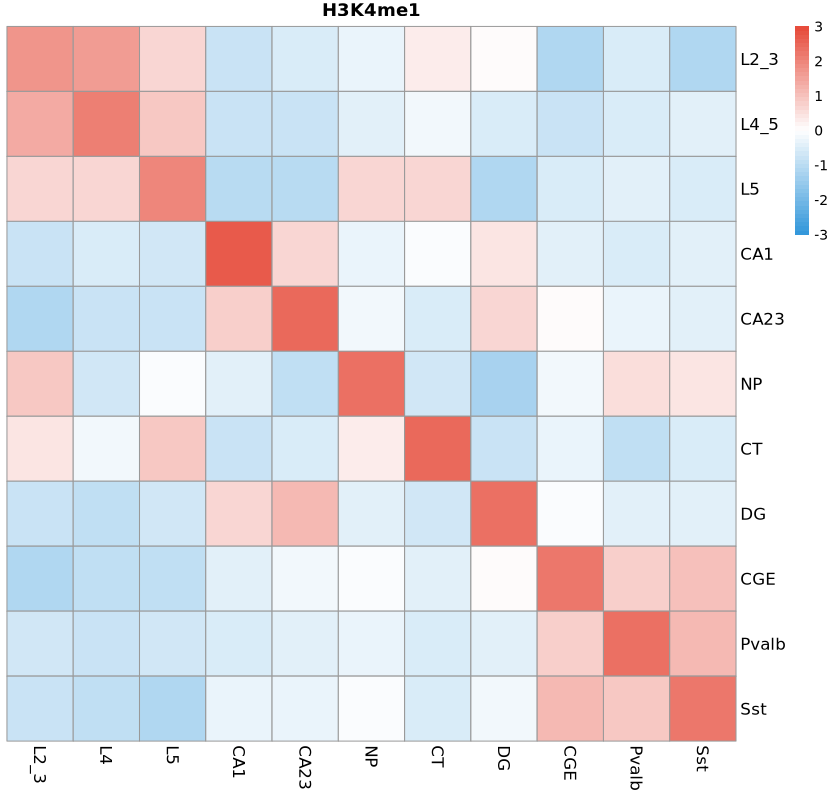

In [61]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me1",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

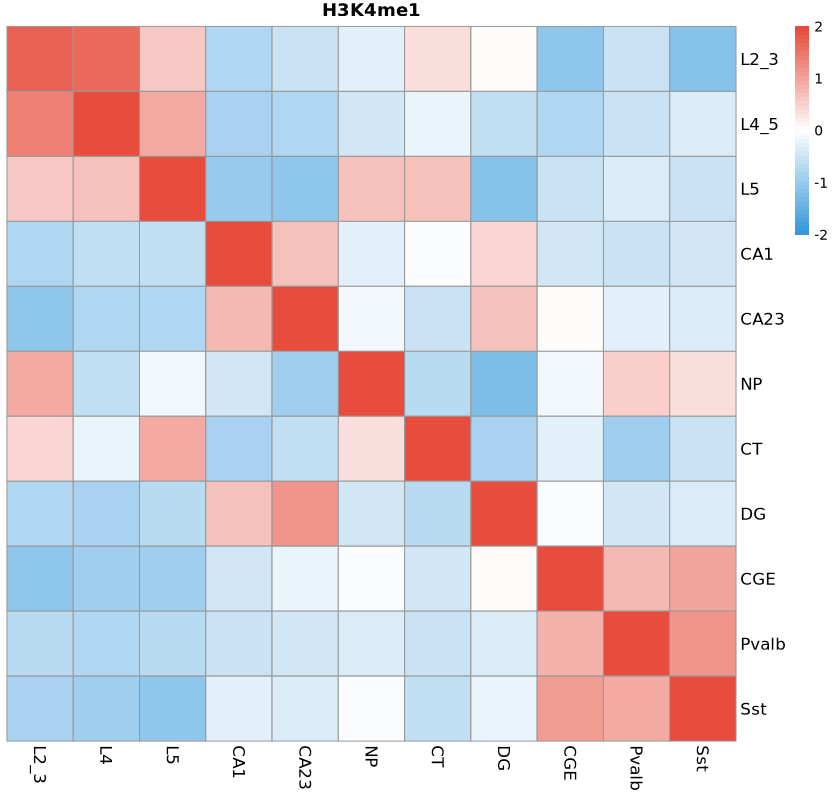

In [62]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me1",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

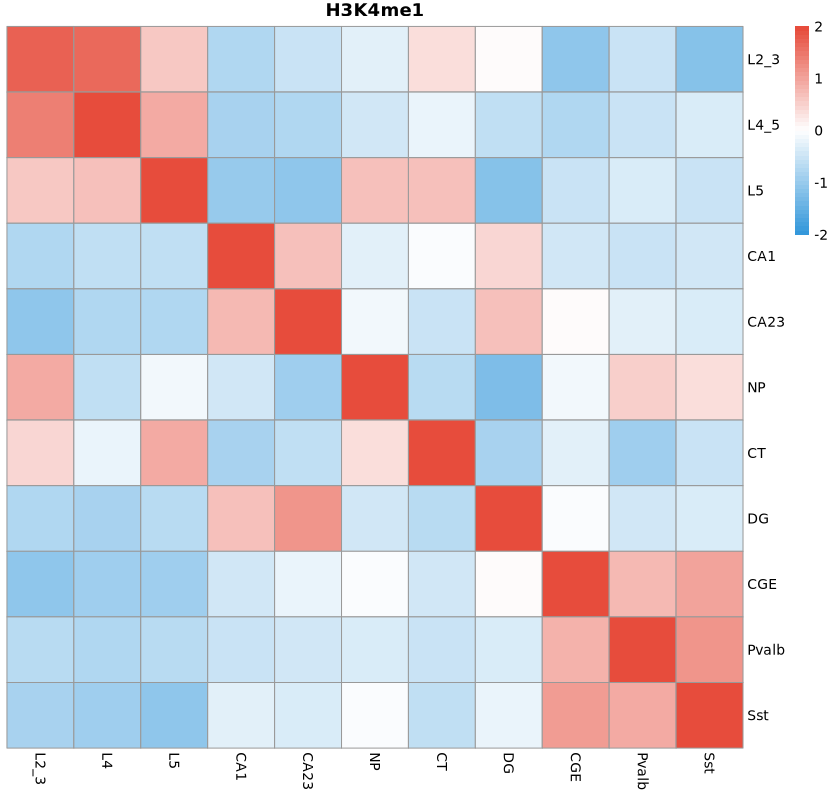

In [63]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me1",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

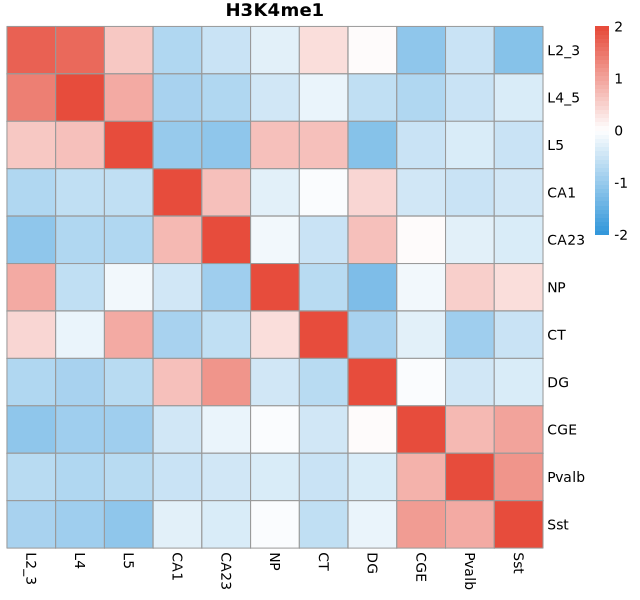

In [64]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [ ]:
pdf("../../../output/01-youth/07-Histone/01-heatmap/08-H3K4me1_modification_in_hyperDHMR_merge_v3.pdf",width = 6.4,height = 6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!